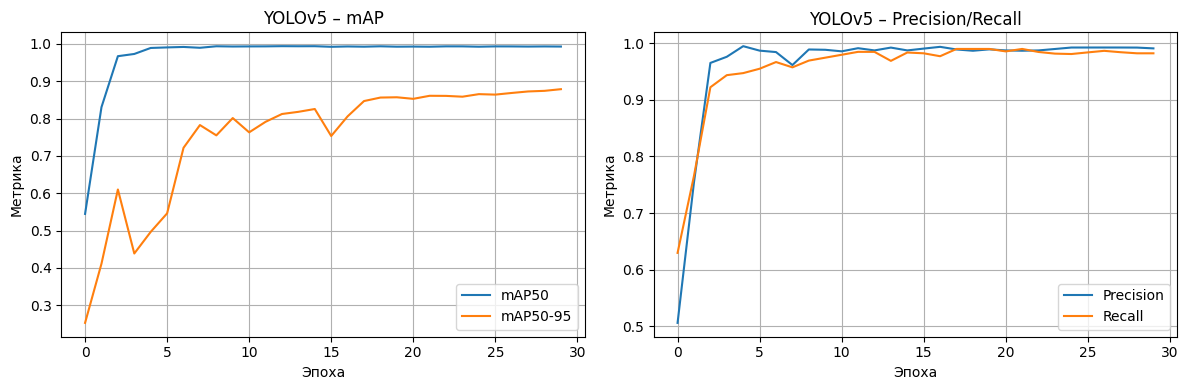

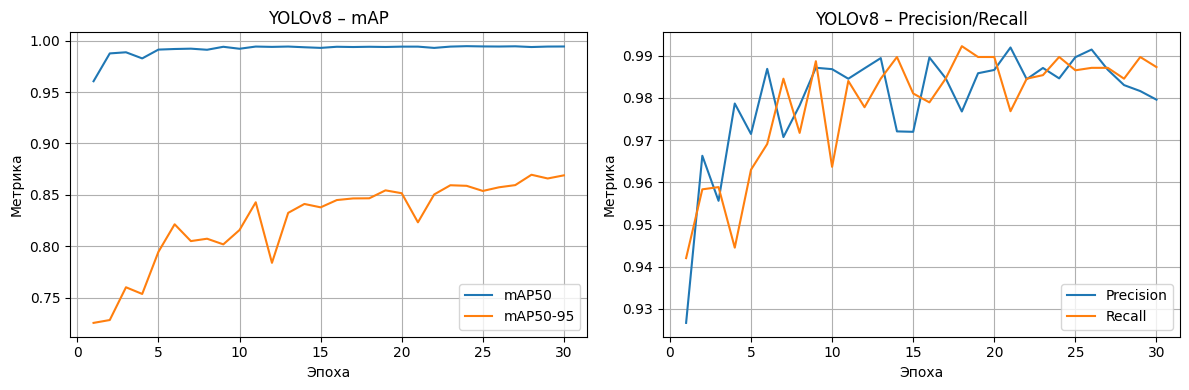

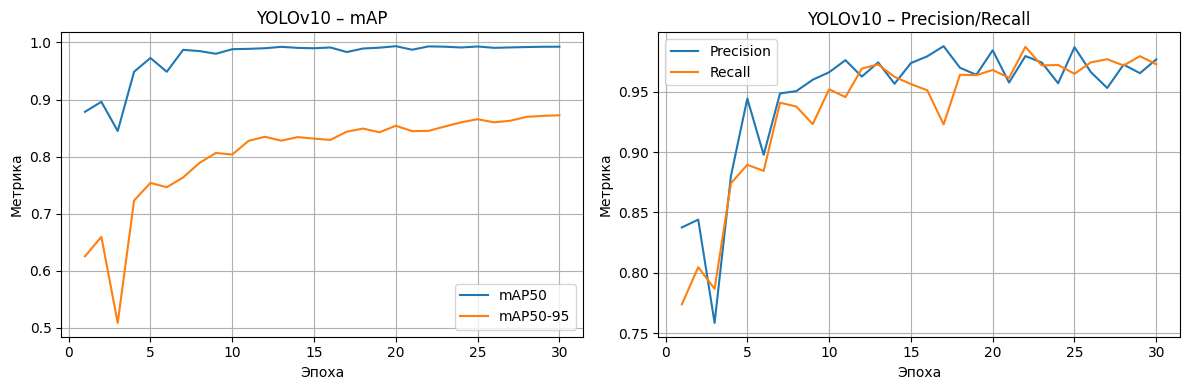

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_metrics(csv_path, model_name):
    df = pd.read_csv(csv_path)
    # Очищаем имена столбцов от пробелов в начале/конце
    df.columns = df.columns.str.strip()

    # Определяем названия столбцов для каждой модели
    if model_name == 'YOLOv5':
        map50 = 'metrics/mAP_0.5'
        map50_95 = 'metrics/mAP_0.5:0.95'
        prec = 'metrics/precision'
        rec = 'metrics/recall'
    else:  # YOLOv8 / YOLOv10
        map50 = 'metrics/mAP50(B)'
        map50_95 = 'metrics/mAP50-95(B)'
        prec = 'metrics/precision(B)'
        rec = 'metrics/recall(B)'

    # Проверяем, что все нужные столбцы есть
    for col in ['epoch', map50, map50_95, prec, rec]:
        if col not in df.columns:
            print(f"Предупреждение: столбец '{col}' не найден в {csv_path}, пропускаем")
            return

    # Построение графиков
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(df['epoch'], df[map50], label='mAP50')
    plt.plot(df['epoch'], df[map50_95], label='mAP50-95')
    plt.xlabel('Эпоха')
    plt.ylabel('Метрика')
    plt.title(f'{model_name} – mAP')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(df['epoch'], df[prec], label='Precision')
    plt.plot(df['epoch'], df[rec], label='Recall')
    plt.xlabel('Эпоха')
    plt.ylabel('Метрика')
    plt.title(f'{model_name} – Precision/Recall')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{model_name}_curves.png', dpi=300)
    plt.show()

# Запуск для всех трёх моделей
plot_metrics('results_yolov5.csv', 'YOLOv5')
plot_metrics('results_yolov8.csv', 'YOLOv8')
plot_metrics('results_yolov10.csv', 'YOLOv10')
